# Investigating Unfairness

In [17]:
import matplotlib.pyplot as plt
import duckdb as ddb
import numpy as np
from pathlib import Path
import pandas as pd

## Loading

In [18]:
ROOT = Path.cwd().resolve().parents[1]
RESULTS_DIR = ROOT / "results/"
DATA_DIR = ROOT / "datasets/cloud_energy_consumption"

con = ddb.connect(database=':memory:')

In [19]:
def load_experiment(name, path):
    con.execute(f"""
        CREATE OR REPLACE VIEW {name} AS
        SELECT *
        FROM read_parquet('{RESULTS_DIR / path["path"]}')
    """)

In [20]:
# User data
con.query(f"""CREATE OR REPLACE TABLE vmhardware AS SELECT * FROM read_csv('{DATA_DIR}/vms/2024-12-14T000000Z_2025-04-13T235959Z/vms_fixed.csv')""")
vm_user = con.query("""SELECT vm_id, user_id from vmhardware""").df()

### Placements

In [21]:
PLACEMENT_EXPERIMENTS = {
        "rc_pbfd": {
            "path": "RC_PBFD/placements_RC_PBFD.parquet",
            "label": "RC + POWER - 10-90",
            "group": "RC",
        },
        "rc_bfd": {
            "path": "RC_BFD_CPU/placements_RC_BFD_CPU.parquet",
            "label": "RC + CPU + 10-90",
            "group": "RC",
        },    
        "mm_pbfd_30_no_cpu": {
            "path": "MM_PBFD_0_30_NO_CPU/placements_MM_PBFD_0_30_NO_CPU.parquet",
            "label": "MM + POWER + 0-30",
            "group": "MM",
        },
        "mm_pbfd_10_30_no_cpu": {
            "path": "MM_PBFD_10_30_NO_CPU/placements_MM_PBFD_10_30_NO_CPU.parquet",
            "label": "MM + POWER + 10-30 + NO CPU",
            "group": "MM",
        },
        "mm_pbfd_10_30": {
            "path": "MM_PBFD_10_30/placements_MM_PBFD_10_30.parquet",
            "label": "MM + POWER + 10-30",
            "group": "MM",
        },
        "rc_pbfd_10_30": {
            "path": "RC_PBFD_10_30/placements_RC_PBFD_10_30.parquet",
            "label": "RC + POWER + 10-30",
            "group": "RC",
        },
        "rc_pbfd_20": {
            "path": "RC_PBFD_20/placements_RC_PBFD_20.parquet",
            "label": "RC + POWER + 20-90",
            "group": "RC",
        },
        "rc_cpu_bfd_20": {
            "path": "RC_CPU_BFD_20/placements_RC_CPU_BFD_20.parquet",
            "label": "RC + CPU + 20-90",
            "group": "RC",
        },
    }

for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    load_experiment(view_name, cfg)

### Simulations

In [ ]:
SIMULATION_EXPERIMENTS = {
        "rc_pbfd_sim": {
            "path": "RC_PBFD/simulated_RC_PBFD.parquet",
            "label": "RC + POWER - 10-90",
            "group": "RC",
        },
        "rc_bfd_sim": {
            "path": "RC_BFD_CPU/simulated_RC_BFD_CPU.parquet",
            "label": "RC + CPU + 10-90",
            "group": "RC",
        },    
        "mm_pbfd_30_no_cpu_sim": {
            "path": "MM_PBFD_0_30_NO_CPU/simulated_MM_PBFD_0_30_NO_CPU.parquet",
            "label": "MM + POWER + 0-30",
            "group": "MM",
        },
        "mm_pbfd_10_30_no_cpu_sim": {
            "path": "MM_PBFD_10_30_NO_CPU/simulated_MM_PBFD_10_30_NO_CPU.parquet",
            "label": "MM + POWER + 10-30 + NO CPU",
            "group": "MM",
        },
        "mm_pbfd_10_30_sim": {
            "path": "MM_PBFD_10_30/simulated_MM_PBFD_10_30.parquet",
            "label": "MM + POWER + 10-30",
            "group": "MM",
        },
        "rc_pbfd_10_30_sim": {
            "path": "RC_PBFD_10_30/simulated_RC_PBFD_10_30.parquet",
            "label": "RC + POWER + 10-30",
            "group": "RC",
        },
        "rc_pbfd_20_sim": {
            "path": "RC_PBFD_20/simulated_RC_PBFD_20.parquet",
            "label": "RC + POWER + 20-90",
            "group": "RC",
        },
        "rc_cpu_bfd_20_sim": {
            "path": "RC_CPU_BFD_20/simulated_RC_CPU_BFD_20.parquet",
            "label": "RC + CPU + 20-90",
            "group": "RC",
        },
    }

for view_name, cfg in SIMULATION_EXPERIMENTS.items():
    load_experiment(view_name, cfg)

In [9]:
con.query("""SELECT * FROM rc_pbfd LIMIT 5""").show()

┌──────────┬─────────────┬─────────────┬──────────┬────────┬──────────────┐
│  vm_id   │ source_node │ target_node │ vm_power │ vm_cpu │ vm_memory_mb │
│ varchar  │   varchar   │   varchar   │  double  │ double │    double    │
├──────────┼─────────────┼─────────────┼──────────┼────────┼──────────────┤
│ 2952a1f5 │ e4362c19    │ 5180b174    │     0.04 │    1.0 │       2000.0 │
│ 15238002 │ e4362c19    │ 5180b174    │     0.02 │    1.0 │       2000.0 │
│ c3cc7b6e │ e4362c19    │ 5180b174    │     0.02 │    1.0 │       2000.0 │
│ 8c66686c │ e4362c19    │ 5180b174    │     0.02 │    1.0 │       2000.0 │
│ 79ecf890 │ e4362c19    │ 5180b174    │     0.02 │    1.0 │       2000.0 │
└──────────┴─────────────┴─────────────┴──────────┴────────┴──────────────┘



In [10]:
def show_count(experiment):

    print(f"Count unique for {experiment} simulation")

    con.query(f"""
        SELECT
            COUNT(DISTINCT vm_id) AS unique_vm_ids,
            COUNT(DISTINCT source_node) AS unique_source_nodes,
            COUNT(DISTINCT target_node) AS unique_target_nodes
        FROM {experiment}
    """).show()

## Migrations (source to target nodes)

In [ ]:
for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    show_count(view_name)

Count unique for rc_pbfd simulation
┌───────────────┬─────────────────────┬─────────────────────┐
│ unique_vm_ids │ unique_source_nodes │ unique_target_nodes │
│     int64     │        int64        │        int64        │
├───────────────┼─────────────────────┼─────────────────────┤
│           375 │                  77 │                  56 │
└───────────────┴─────────────────────┴─────────────────────┘

Count unique for rc_bfd simulation
┌───────────────┬─────────────────────┬─────────────────────┐
│ unique_vm_ids │ unique_source_nodes │ unique_target_nodes │
│     int64     │        int64        │        int64        │
├───────────────┼─────────────────────┼─────────────────────┤
│           184 │                  53 │                  55 │
└───────────────┴─────────────────────┴─────────────────────┘

Count unique for mm_pbfd_30_no_cpu simulation
┌───────────────┬─────────────────────┬─────────────────────┐
│ unique_vm_ids │ unique_source_nodes │ unique_target_nodes │
│     int64  

## Which users get migrated most
Sorted by migrations and migrations_per_vm

In [22]:
def calc_migrations_per_user(experiment, vm_user):
    
    # select vms and migrations per vm for specific experiment
    vm_migrations = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    user_migrations = vm_migrations.merge(vm_user, on="vm_id", how="left")
    
    user_migrations = user_migrations.groupby("user_id")["migrations"].sum().reset_index()
    
    user_vm_count = vm_user.groupby("user_id")["vm_id"].count().reset_index(name="num_vms")

    user_migrations = user_migrations.merge(user_vm_count, on="user_id")

    user_migrations["migrations_per_vm"] = (
        user_migrations["migrations"] / user_migrations["num_vms"]
    )

    return user_migrations

In [23]:
for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    tbl = calc_migrations_per_user(view_name, vm_user)
    print(f"\n{'='*60}")
    print(f"Experiment : {cfg['label']}")
    print(f"{'='*60}")
    print("\nSorted by total migrations (top 20):")
    print(tbl.sort_values("migrations", ascending=False).head(20).to_string(index=False))
    print("\nSorted by migrations_per_vm (top 20):")
    print(tbl.sort_values("migrations_per_vm", ascending=False).head(20).to_string(index=False))



Experiment : RC + POWER - 10-90

Sorted by total migrations (top 20):
 user_id  migrations  num_vms  migrations_per_vm
f098d7fe       72241       43        1680.023256
7043311c       70684        7       10097.714286
756b77ce       47237       20        2361.850000
8984204a       45202        8        5650.250000
39786247       41594       17        2446.705882
0fb4c56f       32361      102         317.264706
167938a6       30211       16        1888.187500
7f7c4759       30018       72         416.916667
97f5bcf7       29670        6        4945.000000
c0ede4e4       28272       15        1884.800000
17de5058       26234       27         971.629630
4a88a504       23883        9        2653.666667
fe56c37c       16193        4        4048.250000
94d5b733       12818        4        3204.500000
90e4d383       11790        3        3930.000000
c1eb1c1c        9739        6        1623.166667
de65e922        7141        2        3570.500000
a16f591f        6463       26         248.57692

## Correlation Analysis
For each user computes: vm_count, total vCPUs, total memory, average CPU usage, and migrations
Output: correlation matrix distinguishing size-driven migration burdn from workload-driven burden

In [24]:
hw = con.query(f"""
    SELECT user_id,
    COUNT(vm_id) AS vm_count,
    SUM(vcpus) AS total_vcpus,
    SUM(memory_mb) AS total_memory_mb
    FROM vmhardware
    GROUP BY user_id
""").df()

In [28]:
def correlation_analysis(experiment, vm_user, hw):
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    user_mig = (
        vm_mig.merge(vm_user, on="vm_id", how="left")
        .groupby("user_id")["migrations"]
        .sum()
        .reset_index()
    )

    feat = hw.merge(user_mig, on="user_id", how="left")
    feat["migrations"] = feat["migrations"].fillna(0)
    feat["migrations_per_vm"] = feat["migrations"] / feat["vm_count"]

    # Pearson correlation with migrations 
    # TODO: migrations or migrations per vm ??
    cols = ["vm_count", "total_vcpus", "total_memory_mb", "migrations", "migrations_per_vm"]
    #corr = feat[cols].corr()[["migrations_per_vm"]].drop("migrations_per_vm")
    corr = feat[cols].corr()[["migrations"]].drop("migrations")
    corr.columns = ["pearson_r"]

    print(f"\nCorrelation analysis for {experiment}:")
    print(corr.sort_values("pearson_r", ascending=False).to_string())

    return feat


In [29]:
for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    correlation_analysis(view_name, vm_user, hw)


Correlation analysis for rc_pbfd:
                   pearson_r
migrations_per_vm   0.678656
vm_count            0.448174
total_vcpus         0.273894
total_memory_mb     0.261066

Correlation analysis for rc_bfd:
                   pearson_r
migrations_per_vm   0.786951
vm_count            0.480015
total_vcpus         0.410563
total_memory_mb     0.376376

Correlation analysis for mm_pbfd_30_no_cpu:
                   pearson_r
total_vcpus         0.895710
migrations_per_vm   0.865812
vm_count            0.821592
total_memory_mb     0.806310

Correlation analysis for mm_pbfd_10_30_no_cpu:
                   pearson_r
vm_count            0.611595
total_vcpus         0.289290
total_memory_mb     0.249184
migrations_per_vm   0.027441

Correlation analysis for mm_pbfd_10_30:
                   pearson_r
vm_count            0.580077
migrations_per_vm   0.551070
total_vcpus         0.357004
total_memory_mb     0.301140

Correlation analysis for rc_pbfd_10_30:
                   pearson_r
vm

## Lorenz Curve Contribution Analysis
Identifies the top-10% of users by migration burden and calculates what percentage of all migrations they account for. This single number makes fairness results immediately interpretable for thesis readers (e.g. '10% of users account for 60% of all migrations').

In [34]:
def lorenz_contribution(experiment, vm_user, top_pct = 0.10):
    
    # TODO: again, migrations or migrations per vm?
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    user_mig = (
        vm_mig.merge(vm_user, on="vm_id", how="left")
        .groupby("user_id")["migrations"]
        .sum()
        .reset_index()
    )
    # All users in vm_user, even those with 0 migrations
    all_users = vm_user[["user_id"]].drop_duplicates()
    user_mig = all_users.merge(user_mig, on="user_id", how="left").fillna(0)

    vals = user_mig["migrations"].sort_values().values
    n = len(vals)
    total = vals.sum()

    # Curve
    lorenz_y = np.concatenate([[0], np.cumsum(vals) / total])
    lorenz_x = np.linspace(0, 1, n + 1)

    # Gini coefficient
    area = np.trapezoid(lorenz_y, lorenz_x)
    gini = 1 - 2 * area

    # Top contributors
    cutoff_idx = int(np.ceil(n * (1 - top_pct))) # bottom (1-top_pct) users
    top_share = vals[cutoff_idx:].sum() / total if total > 0 else 0.0
    top_n_users = n - cutoff_idx

    result = {
        "experiment": experiment,
        "n_users": n,
        "gini": round(gini, 4),
        "top_pct_label": f"top {int(top_pct*100)}%",
        "top_n_users": top_n_users,
        "top_pct_migration_share": round(top_share, 4),
        "lorenz_x"              : lorenz_x,
        "lorenz_y"              : lorenz_y,
    }

    print(f"\n[{experiment}]")
    print(f"  Users          : {n}")
    print(f"  Gini           : {gini:.4f}")
    print(f"  Top {int(top_pct*100)}% ({top_n_users} users) "
          f"account for {top_share*100:.1f}% of all migrations")
    return result


[rc_pbfd]
  Users          : 61
  Gini           : 0.7527
  Top 10% (6 users) account for 52.1% of all migrations

[rc_bfd]
  Users          : 61
  Gini           : 0.8220
  Top 10% (6 users) account for 65.5% of all migrations

[mm_pbfd_30_no_cpu]
  Users          : 61
  Gini           : 0.9710
  Top 10% (6 users) account for 100.0% of all migrations

[mm_pbfd_10_30_no_cpu]
  Users          : 61
  Gini           : 0.5668
  Top 10% (6 users) account for 38.6% of all migrations

[mm_pbfd_10_30]
  Users          : 61
  Gini           : 0.7580
  Top 10% (6 users) account for 55.1% of all migrations

[rc_pbfd_10_30]
  Users          : 61
  Gini           : 0.7580
  Top 10% (6 users) account for 55.1% of all migrations

[rc_pbfd_20]
  Users          : 61
  Gini           : 0.8058
  Top 10% (6 users) account for 65.7% of all migrations

[rc_cpu_bfd_20]
  Users          : 61
  Gini           : 0.8416
  Top 10% (6 users) account for 75.1% of all migrations


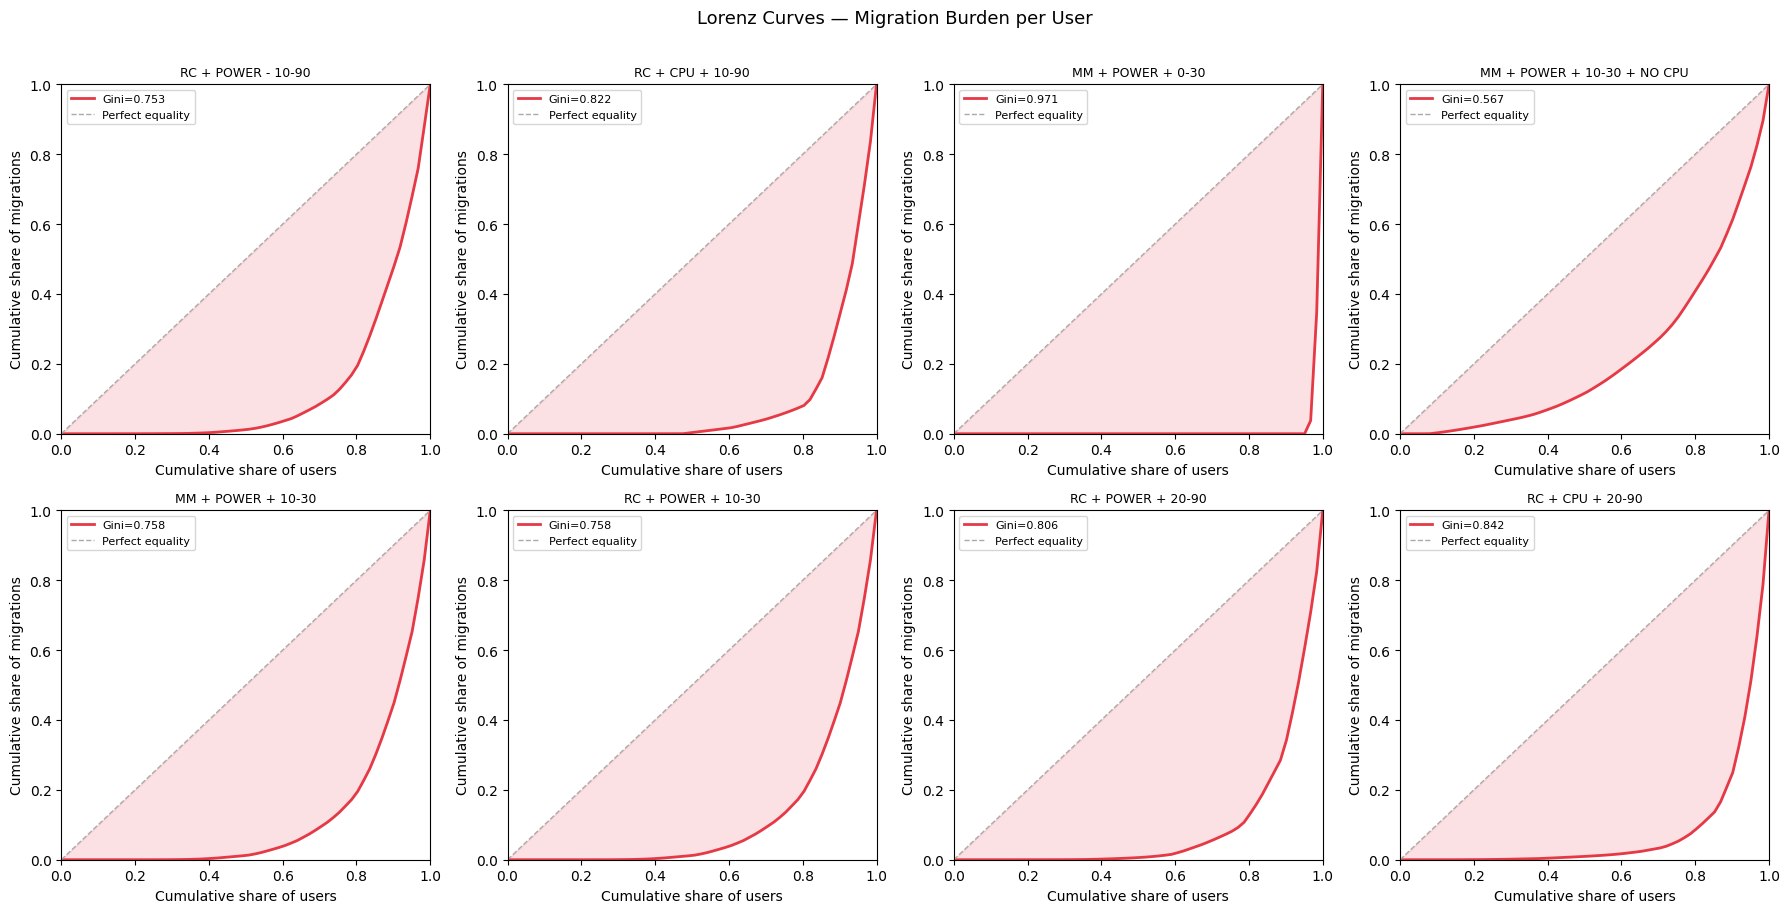

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, (exp_name, cfg) in zip(axes, PLACEMENT_EXPERIMENTS.items()):
    res = lorenz_contribution(exp_name, vm_user)
    ax.plot(res["lorenz_x"], res["lorenz_y"], color="#e63946", lw=2,
            label=f"Gini={res['gini']:.3f}")
    ax.plot([0, 1], [0, 1], "--", color="#aaaaaa", lw=1, label="Perfect equality")
    ax.fill_between(res["lorenz_x"], res["lorenz_y"], res["lorenz_x"],
                    alpha=0.15, color="#e63946")
    ax.set_title(cfg["label"], fontsize=9)
    ax.set_xlabel("Cumulative share of users")
    ax.set_ylabel("Cumulative share of migrations")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.suptitle("Lorenz Curves — Migration Burden per User", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("lorenz_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## User Group Analysis

Segments users into Small (1–5 VMs), Medium (6–20 VMs), and Large (>20 VMs). Compares average migrations per user, migrations per VM, and migration frequency across groups to reveal whether consolidation systematically disadvantages large tenants.


In [43]:
def group_size(num_vms):
        if num_vms <= 5:
            return "Small (1-5)"
        elif num_vms <= 20:
            return "Medium (6-20)"
        else:
            return "Large (>20)"

In [44]:
def user_group_analysis(experiment, vm_user):
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    user_mig = (
        vm_mig.merge(vm_user, on="vm_id", how="left")
        .groupby("user_id")["migrations"]
        .sum()
        .reset_index()
    )

    user_vm_count = (
        vm_user.groupby("user_id")["vm_id"]
        .count()
        .reset_index(name="num_vms")
    )

    feat = user_vm_count.merge(user_mig, on="user_id", how="left").fillna(0)
    feat["migrations_per_vm"] = feat["migrations"] / feat["num_vms"]


    feat["group"] = feat["num_vms"].apply(group_size)


    group_order = ["Small (1-5)", "Medium (6-20)", "Large (>20)"]

    summary = ( 
        feat.groupby("group")
        .agg(
            n_users          = ("user_id",         "count"),
            avg_migrations   = ("migrations",      "mean"),
            avg_migrations_vm= ("migrations_per_vm","mean"),
            median_migrations= ("migrations", "median"),
            total_migrations = ("migrations", "sum"),
        )
        .reindex(group_order)
        .reset_index()
    )

    summary["avg_migrations"]    = summary["avg_migrations"].round(2)
    summary["avg_migrations_vm"] = summary["avg_migrations_vm"].round(3)
    summary["median_migrations"] = summary["median_migrations"].round(1)

    print(f"\n[{experiment}] — User Group Migration Summary")
    print(summary.to_string(index=False))

    # BAR PLOT
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    colors_map = {"Small (1-5)": "#4a90d9",
                "Medium (6-20)": "#f5a623",
                "Large (>20)": "#e63946"}
    
    bar_colors = [colors_map[g] for g in summary["group"]]
    
    for ax, col, ylabel in zip(
        axes,
        ["avg_migrations", "avg_migrations_vm", "median_migrations"],
        ["Avg migrations / user", "Avg migrations / VM", "Median migrations / user"]
    ):
        ax.bar(summary["group"], summary[col], color=bar_colors)
        ax.set_title(ylabel, fontsize=10)
        ax.set_xlabel("User size group")
        ax.tick_params(axis='x', rotation=15)
        
    fig.suptitle(f"User Group Analysis — {experiment}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"user_group_analysis_{experiment}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return summary


[rc_pbfd] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36         2316.17            911.994              415.5           83382.0
Medium (6-20)       18        18784.28           1927.213             7499.0          338117.0
  Large (>20)        7        24646.00            540.693            26234.0          172522.0


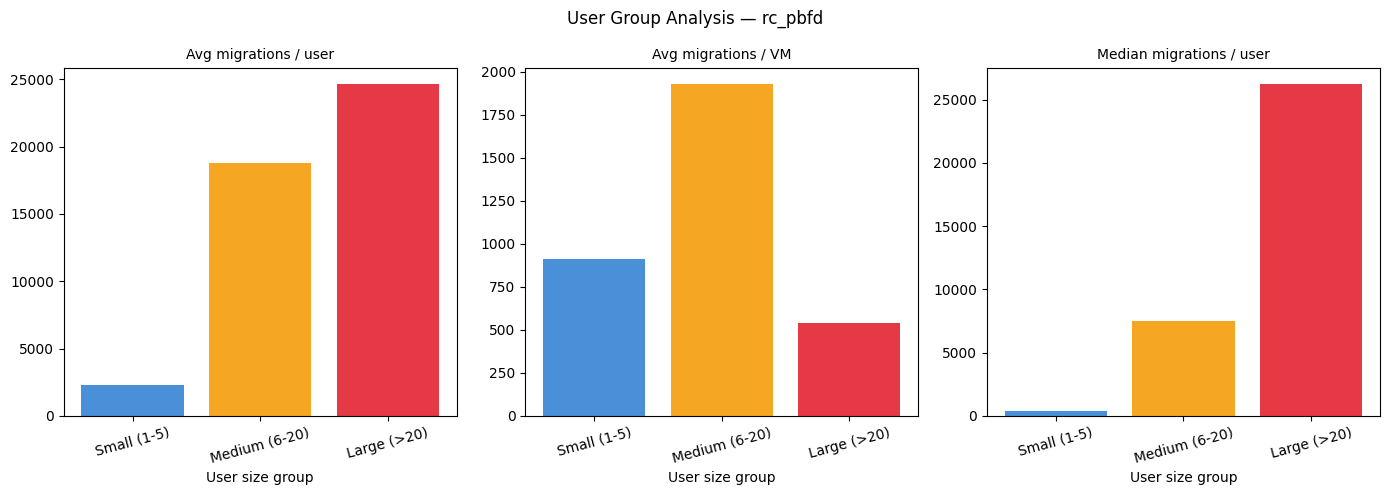


[rc_bfd] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36          869.81            366.843                5.5           31313.0
Medium (6-20)       18        12903.39           1365.929             1827.0          232261.0
  Large (>20)        7        19054.43            416.898            22596.0          133381.0


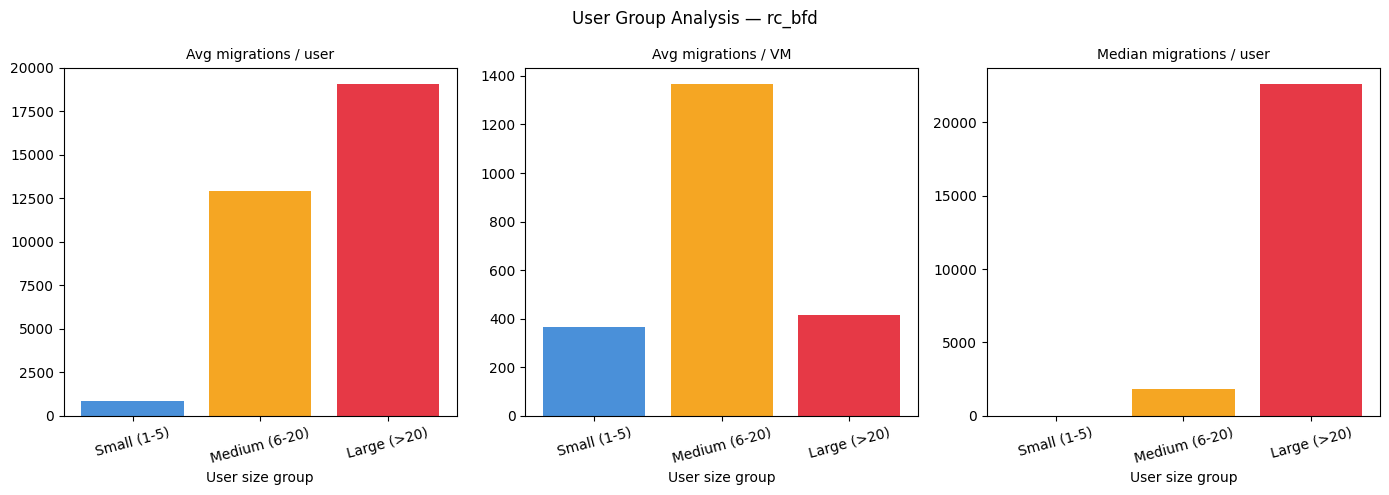


[mm_pbfd_30_no_cpu] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36            0.17              0.033                0.0               6.0
Medium (6-20)       18          695.83             86.979                0.0           12525.0
  Large (>20)        7        45773.29            509.000                0.0          320413.0


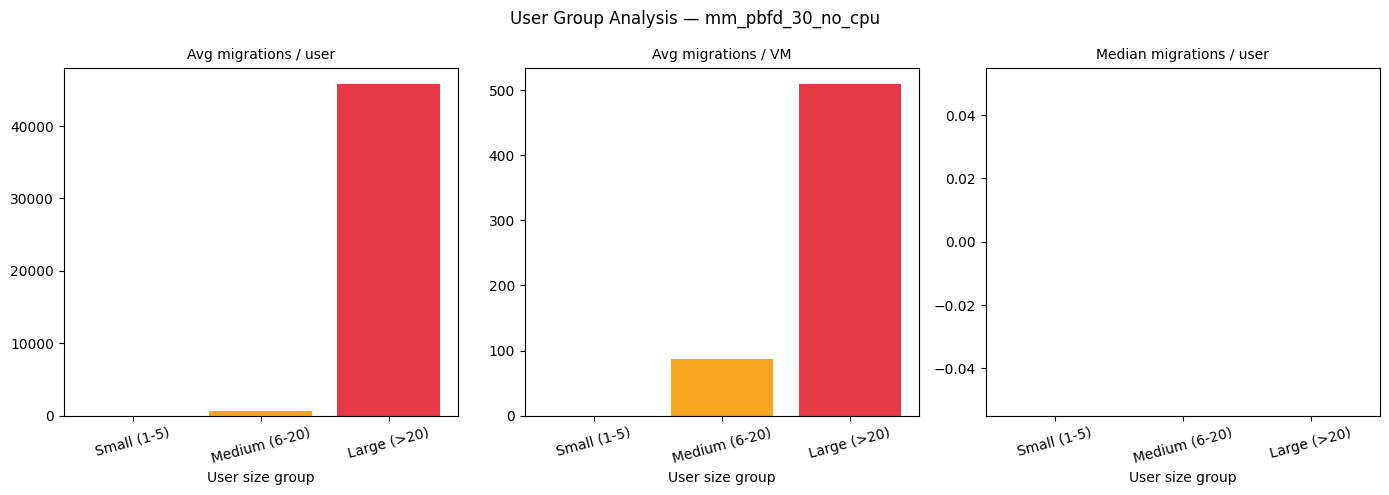


[mm_pbfd_10_30_no_cpu] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36        61019.56          28785.126            40419.0         2196704.0
Medium (6-20)       18       274358.39          26969.988           267801.5         4938451.0
  Large (>20)        7       585143.14          15562.344           572319.0         4096002.0


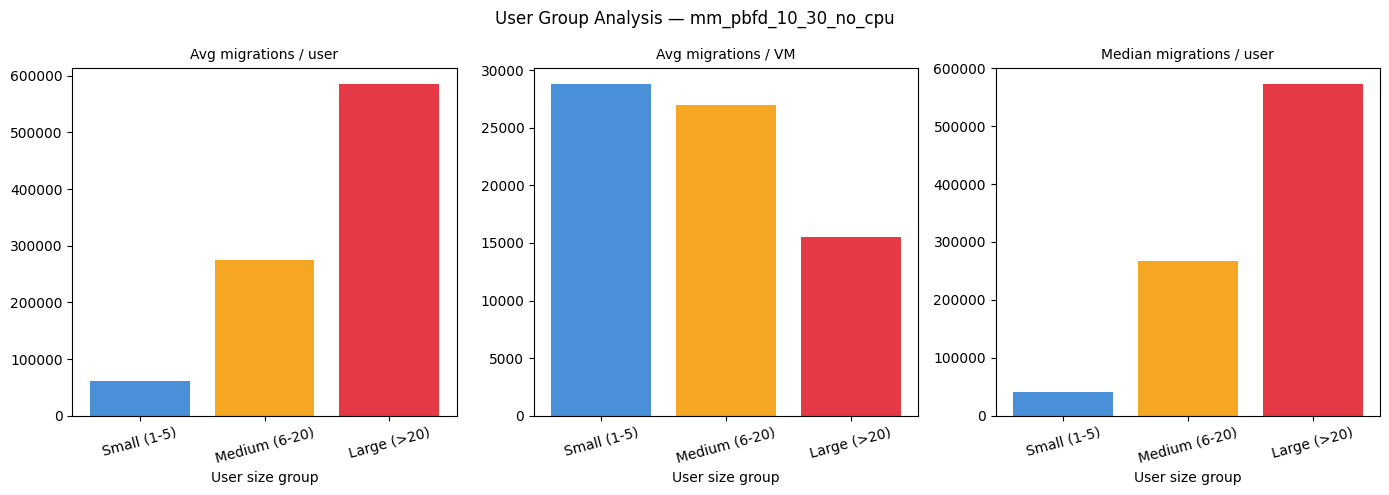


[mm_pbfd_10_30] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36         1372.64            547.888              268.5           49415.0
Medium (6-20)       18         9594.72            956.723             5628.0          172705.0
  Large (>20)        7        17081.29            355.356            10804.0          119569.0


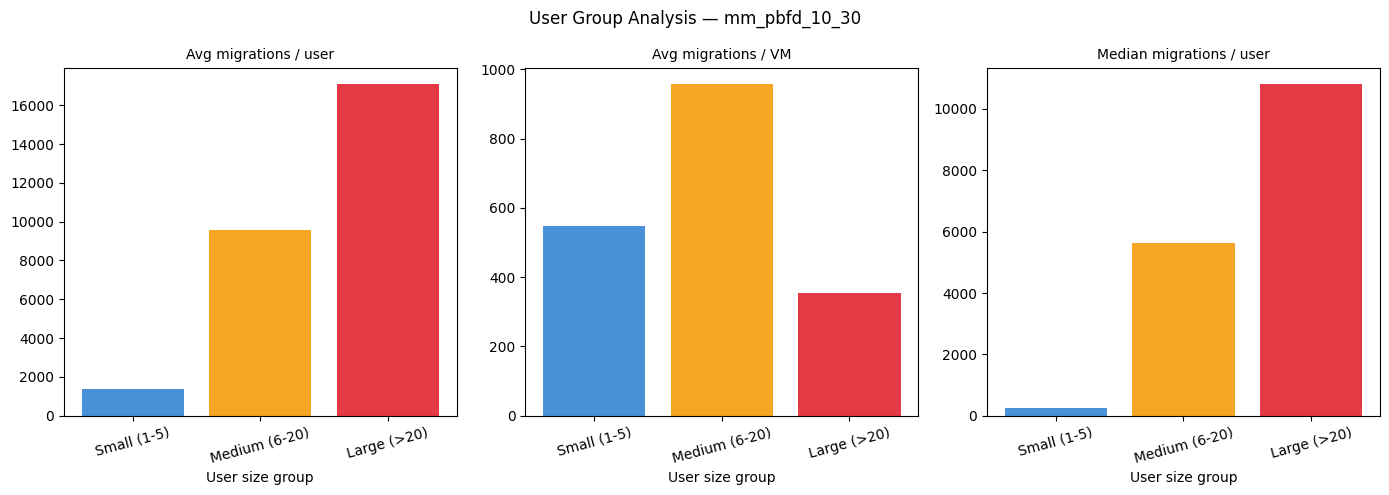


[rc_pbfd_10_30] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36         1372.56            547.889              268.5           49412.0
Medium (6-20)       18         9595.61            956.869             5628.0          172721.0
  Large (>20)        7        17080.57            355.335            10804.0          119564.0


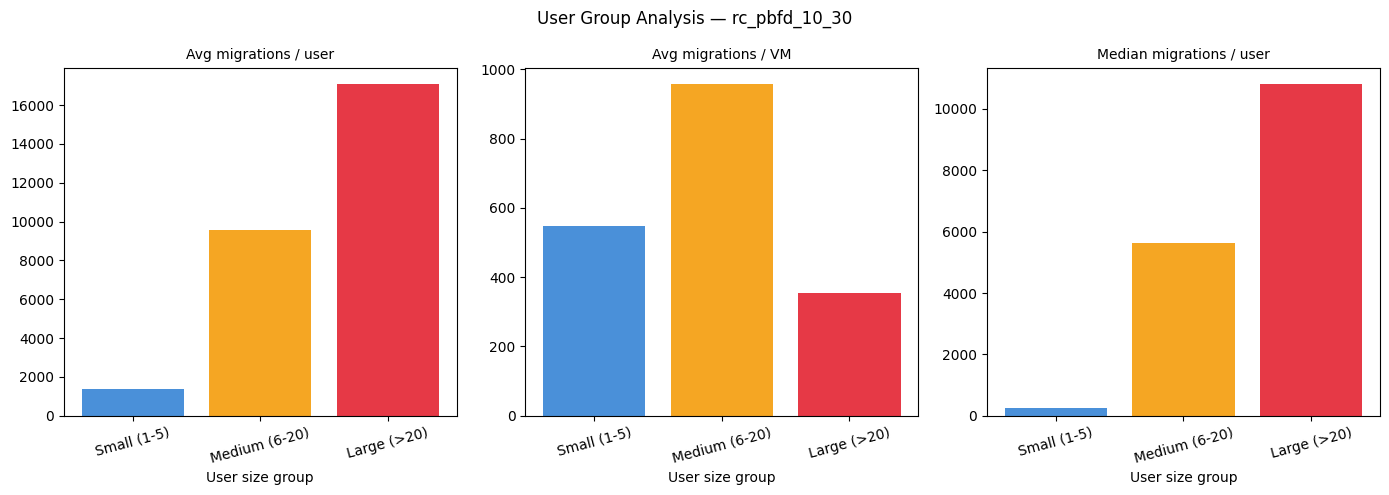


[rc_pbfd_20] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36         1023.28            400.676              172.0           36838.0
Medium (6-20)       18        12260.72           1364.499             4413.5          220693.0
  Large (>20)        7        17137.71            314.980            10829.0          119964.0


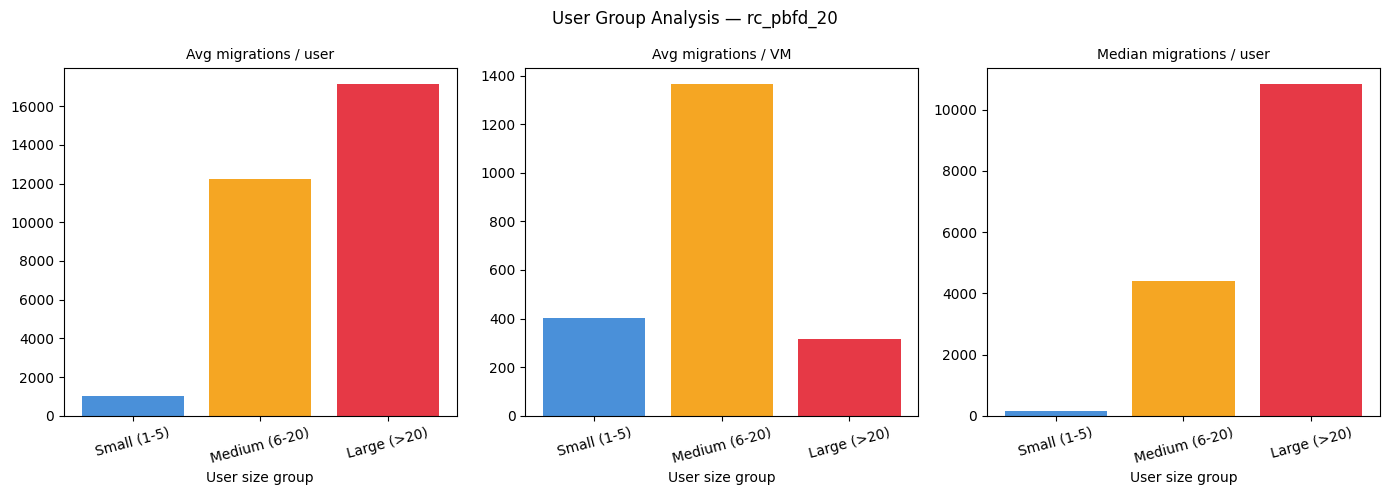


[rc_cpu_bfd_20] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36          844.58            305.903              105.0           30405.0
Medium (6-20)       18         9762.50           1121.844             1030.5          175725.0
  Large (>20)        7        13423.29            234.958             8724.0           93963.0


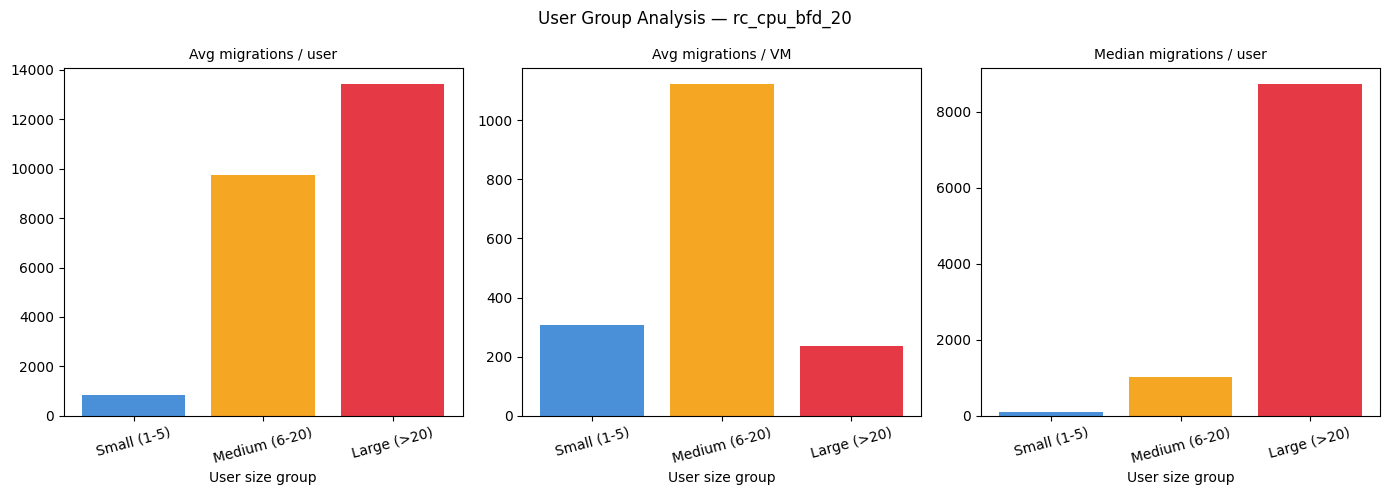

In [45]:
for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    user_group_analysis(view_name, vm_user)

## Project-level fairness
Computes Gini coefficient and Jain's fairness index at the project level in addition to the existing user-level metrics. A result that is unfair by user but fair by project (or vice versa) significantly strengthens the thesis discussion.

In [46]:
def gini(x):
    x = np.array(x)
    if len(x) == 0:
        return 0
    if np.amin(x) < 0:
        x = x - np.amin(x)
    x = np.sort(x)
    cumx = np.cumsum(x)
    return (len(x) + 1 - 2 * np.sum(cumx) / cumx[-1]) / len(x)

def jains_fairness(x):
    x = np.array(x)
    if len(x) == 0:
        return 0
    return (np.sum(x) ** 2) / (len(x) * np.sum(x ** 2))

In [47]:
def project_fairness(experiment, vm_user):
    
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    vm_project = con.query("""
        SELECT vm_id, project_id
        FROM vmhardware
    """).df()
    
    merged = vm_project.merge(vm_mig, on="vm_id", how="left").fillna(0)

    project_mig = merged.groupby("project_id")["migrations"].sum().reset_index(name="migrations")

    # computing fairness metrics (per migration count)
    vals = project_mig["migrations"].values

    gini_coeff = gini(vals)
    jains = jains_fairness(vals)

    print(f"\n[{experiment}] — Project-Level Fairness")
    print(f"  Projects : {len(project_mig)}")
    print(f"  Gini     : {gini_coeff:.4f}  (0 = equal, 1 = one project gets all)")
    print(f"  Jain     : {jains:.4f}  (1 = perfectly fair)")

    # per project normalised migrations (migrations / vms in project)
    proj_vm_count = (
        merged.groupby("project_id")["vm_id"]
        .count()
        .reset_index(name="vm_count")
    )

    project_mig = project_mig.merge(proj_vm_count, on="project_id")
    project_mig["migrations_per_vm"] = project_mig["migrations"] / project_mig["vm_count"]
    
    print("\nTop 10 projects by migrations:")
    print(
        project_mig.sort_values("migrations", ascending=False)
        .head(10)
        .to_string(index=False)
    )

    return project_mig

In [49]:
for exp_name, cfg in PLACEMENT_EXPERIMENTS.items():
    project_fairness(exp_name, vm_user)


[rc_pbfd] — Project-Level Fairness
  Projects : 55
  Gini     : 0.7602  (0 = equal, 1 = one project gets all)
  Jain     : 0.2466  (1 = perfectly fair)

Top 10 projects by migrations:
project_id  migrations  vm_count  migrations_per_vm
  c5e1c75e     72241.0        43        1680.023256
  7d4a4a5a     71596.0        68        1052.882353
  0e0251eb     70684.0         7       10097.714286
  7fdd1b8b     54132.0        10        5413.200000
  50c87cc4     35189.0        11        3199.000000
  f09054da     31903.0        27        1181.592593
  089f5c7f     31673.0        13        2436.384615
  0cbb333b     31624.0         6        5270.666667
  e7f3706a     28272.0        15        1884.800000
  17964622     25781.0         4        6445.250000

[rc_bfd] — Project-Level Fairness
  Projects : 55
  Gini     : 0.8180  (0 = equal, 1 = one project gets all)
  Jain     : 0.1892  (1 = perfectly fair)

Top 10 projects by migrations:
project_id  migrations  vm_count  migrations_per_vm
  0e025

Builds a side-by-side table of Gini/Jain by user AND by project for every experiment. Reveals discrepancies between the two levels.

In [48]:
def fairness_comparison_table(vm_user):
    rows = []

    for exp_name, cfg in PLACEMENT_EXPERIMENTS.items():
        # user-level
        vm_mig = con.query(f"""SELECT vm_id, COUNT(*) AS migrations FROM {exp_name} GROUP BY vm_id""").df()
        
        user_mig = (
            vm_mig.merge(vm_user, on="vm_id", how="left")
            .groupby("user_id")["migrations"]
            .sum()
            .reset_index()
        )

        all_users = vm_user[["user_id"]].drop_duplicates()
        user_vals = (
            all_users.merge(user_mig, on="user_id", how="left").fillna(0)["migrations"].values
        )

        # project-level
        vm_project = con.query("""SELECT vm_id, project_id FROM vmhardware""").df()

        project_vals = (
            vm_mig.merge(vm_project, on="vm_id", how="left")
            .groupby("project_id")["migrations"].sum().values
        )

        rows.append({
            "experiment": cfg["label"],
            "user_gini": round(gini(user_vals), 4),
            "user_jain": round(jains_fairness(user_vals), 4),
            "project_gini": round(gini(project_vals), 4),
            "project_jain": round(jains_fairness(project_vals), 4),
        })

    df = pd.DataFrame(rows)
    print("\nFairness Comparison Table (User vs Project):")
    print(df.to_string(index=False))
    return df

In [50]:
comparison = fairness_comparison_table(vm_user)


Fairness Comparison Table (User vs Project):
                 experiment  user_gini  user_jain  project_gini  project_jain
         RC + POWER - 10-90     0.7527     0.2518        0.7414        0.2659
           RC + CPU + 10-90     0.8220     0.1788        0.7775        0.2313
          MM + POWER + 0-30     0.9710     0.0313        0.4624        0.5390
MM + POWER + 10-30 + NO CPU     0.5668     0.4098        0.5444        0.3753
         MM + POWER + 10-30     0.7580     0.2389        0.7376        0.2667
         RC + POWER + 10-30     0.7580     0.2389        0.7376        0.2667
         RC + POWER + 20-90     0.8058     0.1875        0.7824        0.2190
           RC + CPU + 20-90     0.8416     0.1455        0.8300        0.1587
